<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/Eksperimenter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FoR-dataset

Load the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
drive_path = "/content/drive/MyDrive/Speciale/for-rerecorded 2"
!cp -r "{drive_path}" /content/for-rerec

Check the split og the data

In [4]:
import os

for split in ["training", "validation", "testing"]:
    for label in ["real", "fake"]:
        path = f"/content/for-rerec/{split}/{label}"
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"{split}/{label}: {count} files")

training/real: 5104 files
training/fake: 5104 files
validation/real: 1101 files
validation/fake: 1143 files
testing/real: 408 files
testing/fake: 408 files


# Comparison of the different spectrogram types: STFT, MEL, MFCC and CQT

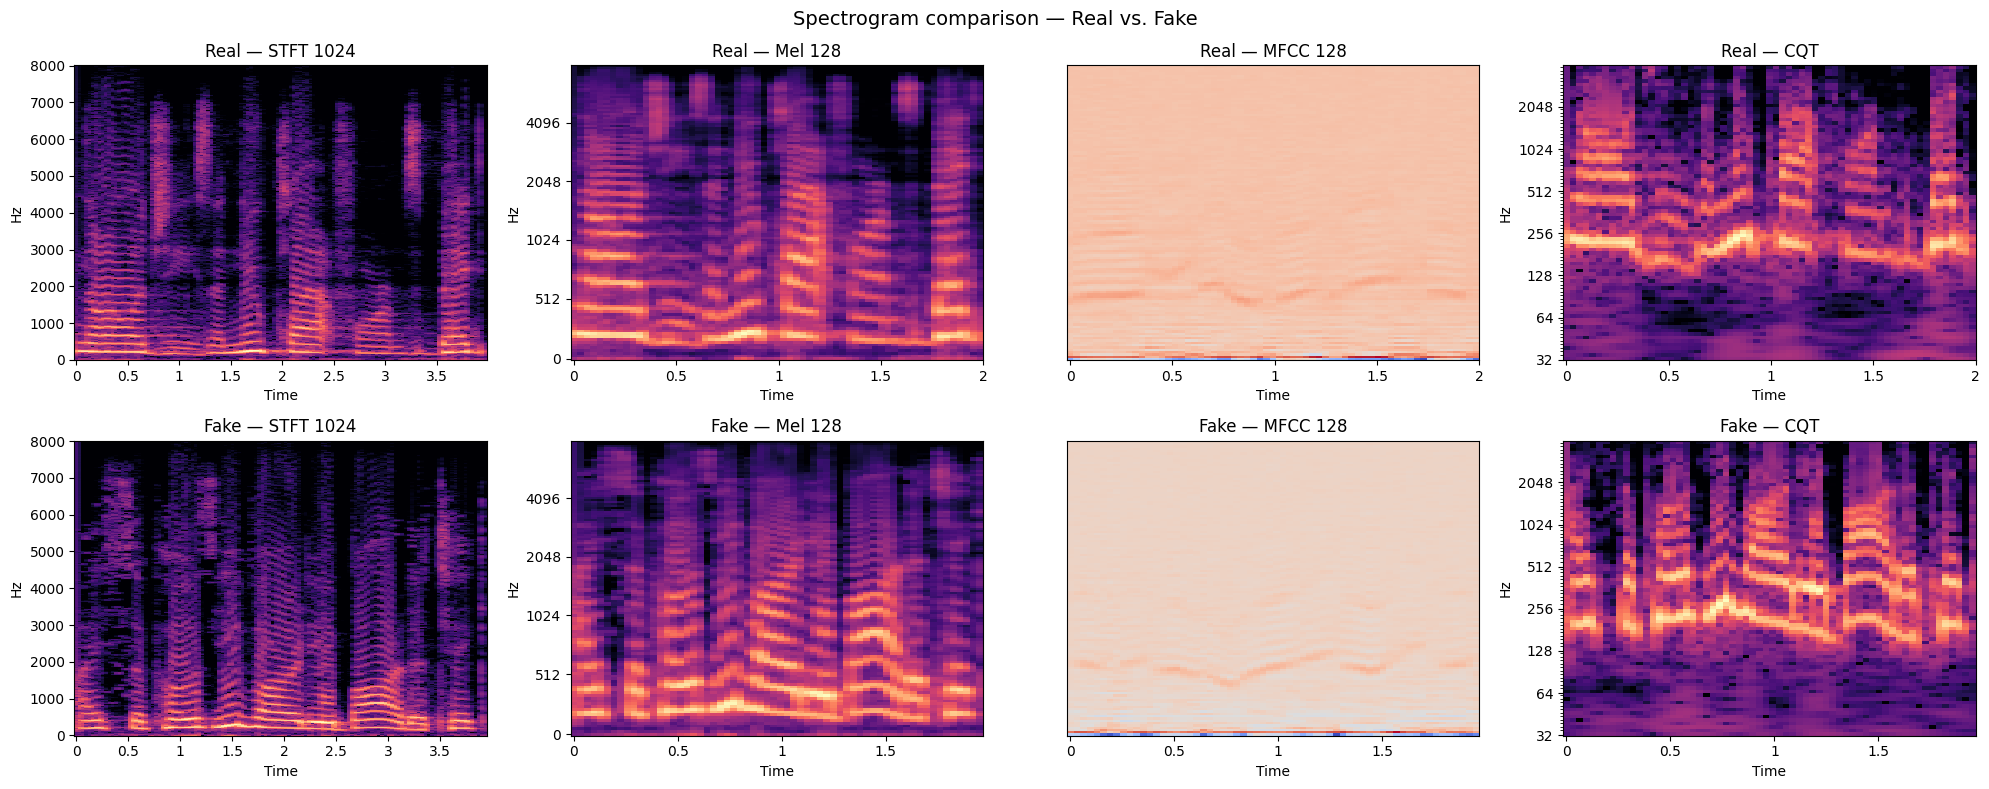

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

real_path = "/content/for-rerec/training/real"
fake_path = "/content/for-rerec/training/fake"

real_file = os.path.join(real_path, os.listdir(real_path)[0])
fake_file = os.path.join(fake_path, os.listdir(fake_path)[0])

def load_spectrograms(file_path):
    y, sr = librosa.load(file_path, sr=None)

    stft = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=1024)), ref=np.max)
    mel  = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=128)
    cqt  = librosa.amplitude_to_db(np.abs(librosa.cqt(y, sr=sr)), ref=np.max)

    return sr, stft, mel, mfcc, cqt

sr_r, stft_r, mel_r, mfcc_r, cqt_r = load_spectrograms(real_file)
sr_f, stft_f, mel_f, mfcc_f, cqt_f = load_spectrograms(fake_file)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Spectrogram comparison — Real vs. Fake", fontsize=14)

librosa.display.specshow(stft_r, sr=sr_r, ax=axes[0,0], x_axis='time', y_axis='hz')
axes[0,0].set_title("Real — STFT 1024")

librosa.display.specshow(mel_r, sr=sr_r, ax=axes[0,1], x_axis='time', y_axis='mel')
axes[0,1].set_title("Real — Mel 128")

librosa.display.specshow(mfcc_r, sr=sr_r, ax=axes[0,2], x_axis='time')
axes[0,2].set_title("Real — MFCC 128")

librosa.display.specshow(cqt_r, sr=sr_r, ax=axes[0,3], x_axis='time', y_axis='cqt_hz')
axes[0,3].set_title("Real — CQT")

librosa.display.specshow(stft_f, sr=sr_f, ax=axes[1,0], x_axis='time', y_axis='hz')
axes[1,0].set_title("Fake — STFT 1024")

librosa.display.specshow(mel_f, sr=sr_f, ax=axes[1,1], x_axis='time', y_axis='mel')
axes[1,1].set_title("Fake — Mel 128")

librosa.display.specshow(mfcc_f, sr=sr_f, ax=axes[1,2], x_axis='time')
axes[1,2].set_title("Fake — MFCC 128")

librosa.display.specshow(cqt_f, sr=sr_f, ax=axes[1,3], x_axis='time', y_axis='cqt_hz')
axes[1,3].set_title("Fake — CQT")

plt.tight_layout()
plt.savefig("spectrogram_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

#Model choices

* Simple CNN – den enkleste model med 3 conv lag (16, 32, 64 filtre), MaxPooling efter hvert lag og et Flatten + Dense lag til sidst. Bruges som reference for at se hvor meget de mere avancerede modeller forbedrer sig.
* Improved CNN – en dybere model med BatchNorm efter hvert conv lag, SeparableConv i residual blocks, GlobalAveragePooling i stedet for Flatten og residual connections der hjælper med at undgå vanishing gradients.
* Improved CNN + SpecAugment – samme arkitektur som Improved CNN men med SpecAugment der tilfældigt maskerer frekvens- og tidsbånd under træning for at forbedre generalisering.
* Mini-Xception – inspireret af Xception arkitekturen, bygger på separable convolutions og residual connections i 4 blokke med stigende antal filtre (32, 64, 128, 256).
* MobileNet – en let pretrained model trænet på ImageNet. Frosne lag bruges som feature extractor og et nyt klassifikationshoved tilføjes oven på.
* VGG16 – en dybere pretrained model med 16 lag. De sidste 5 lag unfreezes så modellen kan fintune sig til spektrogrammer.
* VGG19 – samme som VGG16 men med 19 lag og dermed flere parametre og mere kapacitet.
* ResNet50 – en pretrained model med 50 lag og residual connections indbygget. De sidste 10 lag unfreezes for finetuning.

#STFT

###Imports og parametre

In [3]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR         = 16000
DURATION   = 2.0
TARGET_LEN = int(SR * DURATION)
N_FFT      = 1024
HOP_LENGTH = 256
BATCH_SIZE = 32
EPOCHS     = 50
INITIAL_LR = 3e-4

base_path  = "/content/for-rerec"
train_path = os.path.join(base_path, "training")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "testing")

STFT funktion and load data

In [4]:
def create_stft(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    stft = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    stft_db = librosa.amplitude_to_db(stft, ref=np.max)
    return stft_db.astype(np.float32)

def get_paths(split_path):
    real = sorted([
        os.path.join(split_path, "real", f)
        for f in os.listdir(os.path.join(split_path, "real"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(split_path, "fake", f)
        for f in os.listdir(os.path.join(split_path, "fake"))
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(split_path):
    real, fake = get_paths(split_path)
    X, y = [], []
    for fp in real:
        X.append(create_stft(fp))
        y.append(1)
    for fp in fake:
        X.append(create_stft(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading train...")
X_train, y_train = load_split(train_path)
print("Loading val...")
X_val, y_val = load_split(val_path)
print("Loading test...")
X_test, y_test = load_split(test_path)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Loading train...
Loading val...
Loading test...
Train: (10208, 513, 126)
Val:   (2244, 513, 126)
Test:  (816, 513, 126)


Z-score normalisering

In [5]:
mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)

Train shape: (10208, 513, 126, 1)
Val shape:   (2244, 513, 126, 1)
Test shape:  (816, 513, 126, 1)


Helper function
* CosineAnnealingScheduler – a custom learning rate scheduler. At the start of each epoch it calculates a new learning rate using a cosine curve, starting high at 3e-4 and smoothly decreasing to 1e-6 over all epochs. This helps the model converge more stably than keeping a fixed learning rate.
* get_callbacks – sets up three things that run during training: EarlyStopping stops training if validation loss hasn't improved for 5 epochs, CosineAnnealingScheduler adjusts the learning rate each epoch, and ModelCheckpoint saves the best model to disk whenever validation loss improves.
* equal_error_rate – calculates EER by finding the point where the false acceptance rate equals the false rejection rate. Lower is better.
* bootstrap_ci – estimates how reliable the test accuracy is by randomly resampling the test set 1000 times and computing accuracy each time. This gives a 95% confidence interval so you can say "our accuracy is X ± Y".
* evaluate_model – runs the model on the test set and computes all metrics: accuracy, recall, precision, F1, AUC-ROC, EER and bootstrap confidence interval. Prints them and returns them as a dictionary for the results table.
* plot_history – plots training vs. validation accuracy and loss curves side by side after training so you can see if the model is overfitting.

In [6]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(f"/content/{model_name}.keras", monitor="val_loss", save_best_only=True, verbose=1)
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

SpecAugment og residual block

* SpecAugment – a data augmentation layer that randomly masks out parts of the spectrogram during training only. It applies two masks: a frequency mask that zeros out a random band of frequency bins, and a time mask that zeros out a random slice of time steps. This forces the model to not rely too heavily on specific frequencies or time regions, which helps it generalise better.
* residual_block – a building block for deeper networks. It passes the input through two SeparableConv layers with BatchNorm, then adds the original input (the shortcut) back to the output. This means if the extra layers don't help, the model can just learn to pass the input through unchanged. If the number of filters changes between input and output, a 1x1 Conv is used to match the shapes before adding them together.

In [7]:
class SpecAugment(layers.Layer):
    def __init__(self, freq_mask=10, time_mask=15, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask = freq_mask
        self.time_mask = time_mask

    def call(self, x, training=None):
        if not training:
            return x

        freq = tf.shape(x)[1]
        time = tf.shape(x)[2]

        f  = tf.random.uniform([], 0, self.freq_mask, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, freq - f, dtype=tf.int32)
        freq_mask = 1.0 - tf.cast(
            tf.sequence_mask(f, freq) & ~tf.sequence_mask(f0, freq),
            dtype=x.dtype
        )
        freq_mask = tf.reshape(freq_mask, [1, freq, 1, 1])
        x = x * freq_mask

        t  = tf.random.uniform([], 0, self.time_mask, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, time - t, dtype=tf.int32)
        time_mask = 1.0 - tf.cast(
            tf.sequence_mask(t, time) & ~tf.sequence_mask(t0, time),
            dtype=x.dtype
        )
        time_mask = tf.reshape(time_mask, [1, 1, time, 1])
        x = x * time_mask

        return x

def residual_block(x, filters):
    shortcut = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

###Model 1: Simple CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 513, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 63, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 63, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 31, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 31, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,932,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,955,585 (15.09 MB)

 Trainable params: 3,955,585 (15.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7043 - loss: 0.5609
Epoch 1: val_loss improved from None to 0.26012, saving model to /content/simple_cnn.keras

Epoch 1: finished saving model to /content/simple_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.7981 - loss: 0.4306 - val_accuracy: 0.8939 - val_loss: 0.2601
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9093 - loss: 0.2306
Epoch 2: val_loss improved from 0.26012 to 0.15880, saving model to /content/simple_cnn.keras

Epoch 2: finished saving model to /content/simple_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9147 - loss: 0.2176 - val_accuracy: 0.9389 - val_loss: 0.1588
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9555 - loss: 0.1254
Epoch 3: val_loss improved from 0.15880 to 0.10871, saving model to /content/simple_cnn.keras

Epoch 3: finished saving model to /content/simple_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/s

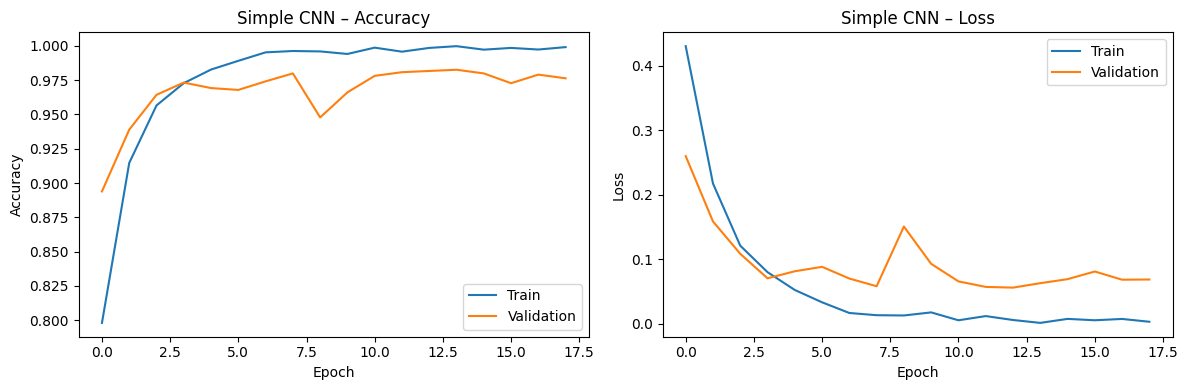


=== Simple CNN ===
Accuracy:  0.7022
Recall:    0.9632
Precision: 0.6329
F1-score:  0.7638
AUC-ROC:   0.8647
EER:       0.1961
Bootstrap: 0.7013 [0.6703, 0.7329]


In [10]:
input_shape = X_train.shape[1:]

simple_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

simple_cnn.summary()

history_simple = simple_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_cnn")
)

plot_history(history_simple, "Simple CNN")
results_simple = evaluate_model(simple_cnn, X_test, y_test, "Simple CNN")

###Model 2: Improved cnn

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 513, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 513, 126,  │        288 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 513, 126,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 256, 63,   │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 63,   │      2,336 │ max_pooling2d_3[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 63,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 63,   │      4,672 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 63,   │      2,048 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 63,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 63,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 31,   │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 31,   │      8,768 │ max_pooling2d_4[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 31,   │        512 │ separable_conv2d

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7811 - loss: 0.4512
Epoch 1: val_loss improved from None to 0.70512, saving model to /content/improved_cnn.keras

Epoch 1: finished saving model to /content/improved_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 79s 159ms/step - accuracy: 0.8496 - loss: 0.3382 - val_accuracy: 0.4906 - val_loss: 0.7051
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9252 - loss: 0.1860
Epoch 2: val_loss did not improve from 0.70512
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - accuracy: 0.9322 - loss: 0.1710 - val_accuracy: 0.4955 - val_loss: 1.9561
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9521 - loss: 0.1276
Epoch 3: val_loss did not improve from 0.70512
319/319 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.9563 - loss: 0.1227 - val_accuracy: 0.5495 - val_loss: 1.7816
Epoch 4/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9621 - loss: 0.1107
Epoch 4: val_loss improved from 0.7051

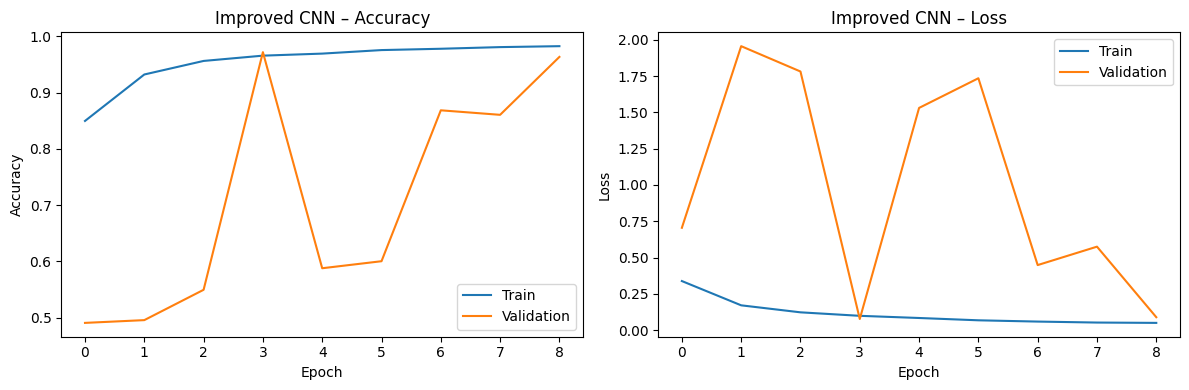


=== Improved CNN ===
Accuracy:  0.6618
Recall:    0.9534
Precision: 0.6022
F1-score:  0.7381
AUC-ROC:   0.8352
EER:       0.2353
Bootstrap: 0.6621 [0.6286, 0.6936]


In [11]:
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn = models.Model(inputs, outputs)
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_cnn.summary()

history_improved = improved_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn")
)

plot_history(history_improved, "Improved CNN")
results_improved = evaluate_model(improved_cnn, X_test, y_test, "Improved CNN")

###Model 3: Improved CNN + SpecAugment

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 513, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spec_augment_2      │ (None, 513, 126,  │          0 │ input_layer_5[0]… │
│ (SpecAugment)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 513, 126,  │        288 │ spec_augment_2[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 256, 63,   │          0 │ activation_26[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_26 │ (None, 256, 63,   │      2,336 │ max_pooling2d_20… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 256, 63,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_27 │ (None, 256, 63,   │      4,672 │ activation_27[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 63,   │      2,048 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 256, 63,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 256, 63,   │          0 │ add_13[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 128, 31,   │          0 │ activation_28[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_28 │ (None, 128, 31,   │      8,768 │ max_pooling2d_21

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7717 - loss: 0.4758
Epoch 1: val_loss improved from None to 1.00844, saving model to /content/improved_cnn_aug.keras

Epoch 1: finished saving model to /content/improved_cnn_aug.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 63s 152ms/step - accuracy: 0.8407 - loss: 0.3639 - val_accuracy: 0.4906 - val_loss: 1.0084
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9295 - loss: 0.1925
Epoch 2: val_loss improved from 1.00844 to 0.52466, saving model to /content/improved_cnn_aug.keras

Epoch 2: finished saving model to /content/improved_cnn_aug.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - accuracy: 0.9357 - loss: 0.1678 - val_accuracy: 0.7170 - val_loss: 0.5247
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9545 - loss: 0.1240
Epoch 3: val_loss did not improve from 0.52466
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - accuracy: 0.9544 - loss: 0.1216 - val_accuracy: 0.6555 - val_loss: 1.059

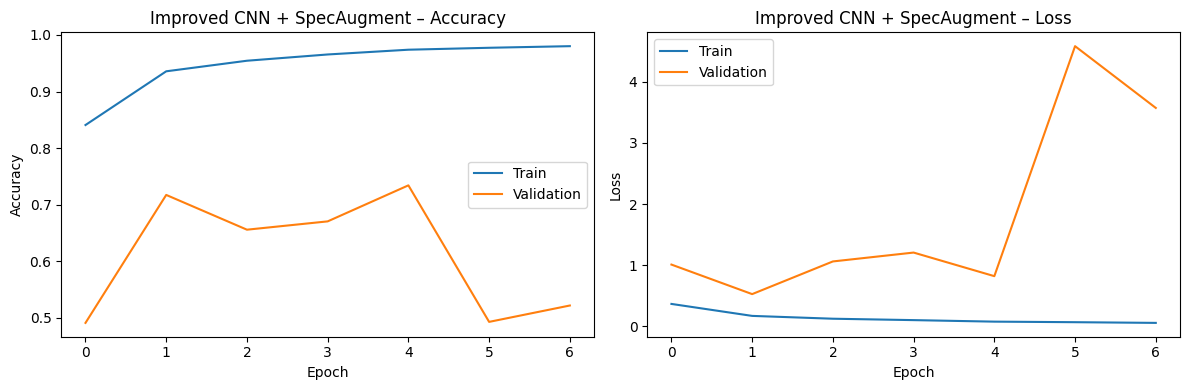


=== Improved CNN + SpecAugment ===
Accuracy:  0.5049
Recall:    1.0000
Precision: 0.5025
F1-score:  0.6689
AUC-ROC:   0.8318
EER:       0.2402
Bootstrap: 0.5052 [0.4706, 0.5380]


In [16]:
inputs = layers.Input(shape=input_shape)
x = SpecAugment()(inputs)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn_aug = models.Model(inputs, outputs)
improved_cnn_aug.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_cnn_aug.summary()

history_improved_aug = improved_cnn_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_aug")
)

plot_history(history_improved_aug, "Improved CNN + SpecAugment")
results_improved_aug = evaluate_model(improved_cnn_aug, X_test, y_test, "Improved CNN + SpecAugment")

###Model 4: Mini-Xception

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 513, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 513, 126,  │        288 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_32 │ (None, 513, 126,  │      1,312 │ activation_33[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_33 │ (None, 513, 126,  │      1,312 │ activation_34[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 257, 63,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 257, 63,   │          0 │ activation_33[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 257, 63,   │          0 │ max_pooling2d_23… │
│                     │ 32)               │            │ max_pooling2d_24… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_34 │ (None, 257, 63,   │      2,336 │ add_16[0][0]      │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 257, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 257, 63,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_35 │ (None, 257, 63,   │      4,672 │ activation_35[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 257, 63,   │      2,048 │ add_16[0][0]    

 Total params: 187,009 (730.50 KB)

 Trainable params: 184,129 (719.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7368 - loss: 0.5536
Epoch 1: val_loss improved from None to 1.42727, saving model to /content/mini_xception.keras

Epoch 1: finished saving model to /content/mini_xception.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 109s 294ms/step - accuracy: 0.8199 - loss: 0.4006 - val_accuracy: 0.4906 - val_loss: 1.4273
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9214 - loss: 0.1813
Epoch 2: val_loss improved from 1.42727 to 0.95180, saving model to /content/mini_xception.keras

Epoch 2: finished saving model to /content/mini_xception.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 81s 255ms/step - accuracy: 0.9321 - loss: 0.1621 - val_accuracy: 0.6542 - val_loss: 0.9518
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9505 - loss: 0.1238
Epoch 3: val_loss improved from 0.95180 to 0.11763, saving model to /content/mini_xception.keras

Epoch 3: finished saving model to /content/mini_xception.keras
319/319 ━━━━━━━

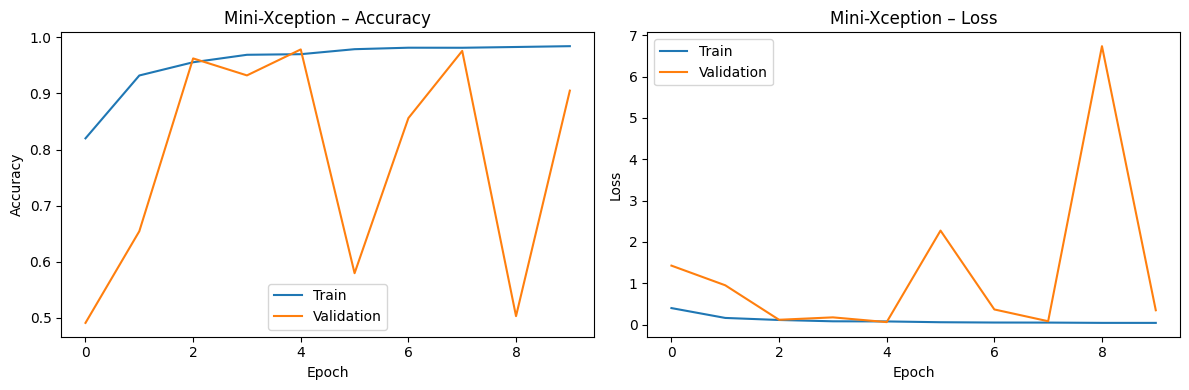


=== Mini-Xception ===
Accuracy:  0.7439
Recall:    0.9608
Precision: 0.6701
F1-score:  0.7895
AUC-ROC:   0.9037
EER:       0.1814
Bootstrap: 0.7439 [0.7145, 0.7745]


In [17]:
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

for filters in [32, 64, 128, 256]:
    residual = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding="same")(x)
    if residual.shape[-1] != filters:
        residual = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(residual)
        residual = layers.BatchNormalization()(residual)
    residual = layers.MaxPooling2D((2,2), padding="same")(residual)
    x = layers.Add()([x, residual])

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mini_xception = models.Model(inputs, outputs)
mini_xception.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mini_xception.summary()

history_xception = mini_xception.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mini_xception")
)

plot_history(history_xception, "Mini-Xception")
results_xception = evaluate_model(mini_xception, X_test, y_test, "Mini-Xception")

###Results for not pretrained

In [18]:
print("Best validation accuracies:")
print(f"Simple CNN:              {max(history_simple.history['val_accuracy']):.4f}")
print(f"Improved CNN:            {max(history_improved.history['val_accuracy']):.4f}")
print(f"Improved CNN + SpecAug:  {max(history_improved_aug.history['val_accuracy']):.4f}")
print(f"Mini-Xception:           {max(history_xception.history['val_accuracy']):.4f}")

Best validation accuracies:
Simple CNN:              0.9826
Improved CNN:            0.9719
Improved CNN + SpecAug:  0.7340
Mini-Xception:           0.9786


In [20]:
all_results = [
    results_simple,
    results_improved,
    results_improved_aug,
    results_xception,
]

df_results = pd.DataFrame(all_results).set_index("model").round(4)
print(df_results.to_string())

                            accuracy  recall  precision      f1     auc     eer  ci_low  ci_high
model                                                                                           
Simple CNN                    0.7022  0.9632     0.6329  0.7638  0.8647  0.1961  0.6703   0.7329
Improved CNN                  0.6618  0.9534     0.6022  0.7381  0.8352  0.2353  0.6286   0.6936
Improved CNN + SpecAugment    0.5049  1.0000     0.5025  0.6689  0.8318  0.2402  0.4706   0.5380
Mini-Xception                 0.7439  0.9608     0.6701  0.7895  0.9037  0.1814  0.7145   0.7745


###Model 5: MobileNet

RGB konvertering til pretrained modeller

In [8]:
def to_rgb_resized(X, size, batch_size=100):
    results = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        batch_rgb = tf.repeat(batch, repeats=3, axis=-1)
        batch_rgb = tf.image.resize(batch_rgb, (size, size)).numpy()
        results.append(batch_rgb.astype(np.float32))
    return np.concatenate(results, axis=0)

X_train_rgb96 = to_rgb_resized(X_train, 96)
X_val_rgb96   = to_rgb_resized(X_val,   96)
X_test_rgb96  = to_rgb_resized(X_test,  96)

X_train_vgg = to_rgb_resized(X_train, 224)
X_val_vgg   = to_rgb_resized(X_val,   224)
X_test_vgg  = to_rgb_resized(X_test,  224)

print("RGB 96:", X_train_rgb96.shape)
print("VGG 224:", X_train_vgg.shape)

RGB 96: (10208, 96, 96, 3)
VGG 224: (10208, 224, 224, 3)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 733,761 (2.80 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

Epoch 1/50
316/319 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7615 - loss: 0.5802
Epoch 1: val_loss improved from None to 1.82717, saving model to /content/mobilenet_finetuned.keras

Epoch 1: finished saving model to /content/mobilenet_finetuned.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.7959 - loss: 0.4756 - val_accuracy: 0.4947 - val_loss: 1.8272
Epoch 2/50
315/319 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8544 - loss: 0.3389
Epoch 2: val_loss did not improve from 1.82717
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8594 - loss: 0.3315 - val_accuracy: 0.4906 - val_loss: 2.4561
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8746 - loss: 0.2906
Epoch 3: val_loss improved from 1.82717 to 0.74201, saving model to /content/mobilenet_finetuned.keras

Epoch 3: finished saving model to /content/mobilenet_finetuned.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8756 - loss: 0.2910 - val_accuracy: 0.5976 - val_loss: 0.74

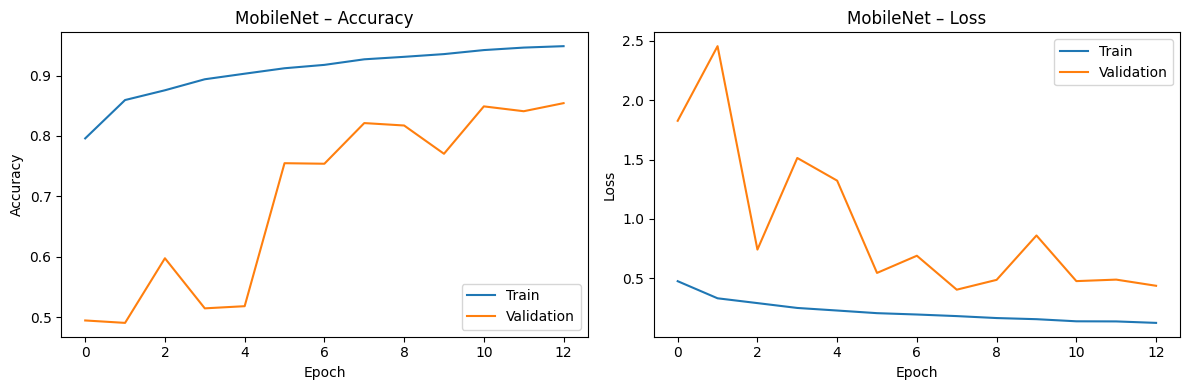


=== MobileNet ===
Accuracy:  0.5490
Recall:    0.6936
Precision: 0.5380
F1-score:  0.6060
AUC-ROC:   0.5800
EER:       0.4436
Bootstrap: 0.5490 [0.5159, 0.5833]


In [9]:
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")

base.trainable = False

inputs  = layers.Input(shape=(96, 96, 3))
x       = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x       = base(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet = models.Model(inputs, outputs)
mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet.summary()

history_mobilenet_1 = mobilenet.fit(
    X_train_rgb96, y_train,
    validation_data=(X_val_rgb96, y_val),
    epochs=10, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mobilenet")
)

base.trainable = True
for layer in base.layers[:-10]:
    layer.trainable = False

mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet.summary()

history_mobilenet_2 = mobilenet.fit(
    X_train_rgb96, y_train,
    validation_data=(X_val_rgb96, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mobilenet_finetuned")
)

plot_history(history_mobilenet_2, "MobileNet")
results_mobilenet = evaluate_model(mobilenet, X_test_rgb96, y_test, "MobileNet")

###Model 6: VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,529 (56.39 MB)

 Trainable params: 7,146,241 (27.26 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8984 - loss: 0.2326
Epoch 1: val_loss improved from None to 0.21530, saving model to /content/vgg16.keras

Epoch 1: finished saving model to /content/vgg16.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 113s 290ms/step - accuracy: 0.9450 - loss: 0.1418 - val_accuracy: 0.9193 - val_loss: 0.2153
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9773 - loss: 0.0619
Epoch 2: val_loss improved from 0.21530 to 0.03810, saving model to /content/vgg16.keras

Epoch 2: finished saving model to /content/vgg16.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 86s 268ms/step - accuracy: 0.9765 - loss: 0.0644 - val_accuracy: 0.9889 - val_loss: 0.0381
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9848 - loss: 0.0441
Epoch 3: val_loss did not improve from 0.03810
319/319 ━━━━━━━━━━━━━━━━━━━━ 85s 266ms/step - accuracy: 0.9861 - loss: 0.0408 - val_accuracy: 0.9416 - val_loss: 0.2050
Epoch 4/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0

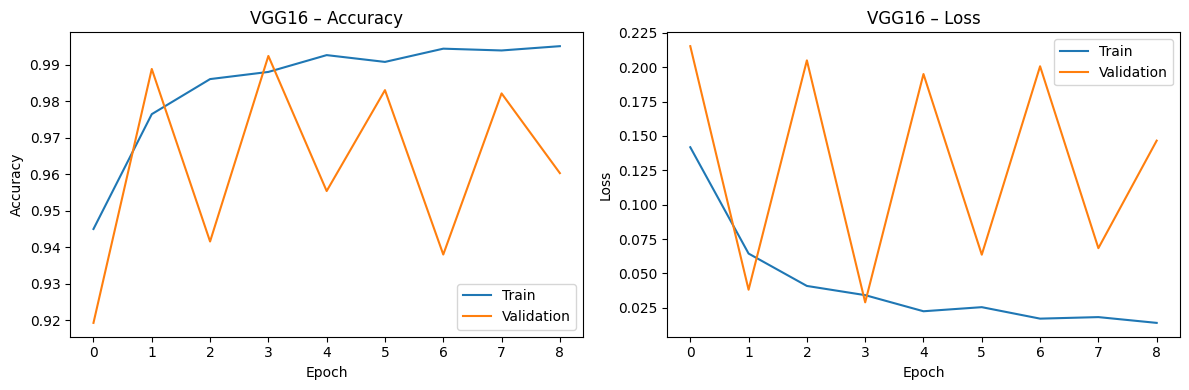


=== VGG16 ===
Accuracy:  0.5478
Recall:    0.9706
Precision: 0.5259
F1-score:  0.6822
AUC-ROC:   0.7427
EER:       0.3260
Bootstrap: 0.5475 [0.5123, 0.5821]


In [10]:
from tensorflow.keras.applications import VGG16

def build_vgg(vgg_class):
    base = vgg_class(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-5:]:
        layer.trainable = True

    inputs  = layers.Input(shape=(224, 224, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation="relu")(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model

vgg16 = build_vgg(VGG16)

history_vgg16 = vgg16.fit(
    X_train_vgg, y_train,
    validation_data=(X_val_vgg, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg16")
)

plot_history(history_vgg16, "VGG16")
results_vgg16 = evaluate_model(vgg16, X_test_vgg, y_test, "VGG16")

###Model 7: VGG19

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,092,225 (76.65 MB)

 Trainable params: 17,765,633 (67.77 MB)

 Non-trainable params: 2,326,592 (8.88 MB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8275 - loss: 0.3870
Epoch 1: val_loss improved from None to 1.65749, saving model to /content/vgg19.keras

Epoch 1: finished saving model to /content/vgg19.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 156s 444ms/step - accuracy: 0.8823 - loss: 0.2843 - val_accuracy: 0.5766 - val_loss: 1.6575
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9450 - loss: 0.1396
Epoch 2: val_loss did not improve from 1.65749
319/319 ━━━━━━━━━━━━━━━━━━━━ 136s 426ms/step - accuracy: 0.9529 - loss: 0.1221 - val_accuracy: 0.5241 - val_loss: 4.0228
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9726 - loss: 0.0823
Epoch 3: val_loss did not improve from 1.65749
319/319 ━━━━━━━━━━━━━━━━━━━━ 136s 425ms/step - accuracy: 0.9715 - loss: 0.0809 - val_accuracy: 0.4955 - val_loss: 6.7879
Epoch 4/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9819 - loss: 0.0514
Epoch 4: val_loss did not improve from 1.65749
31

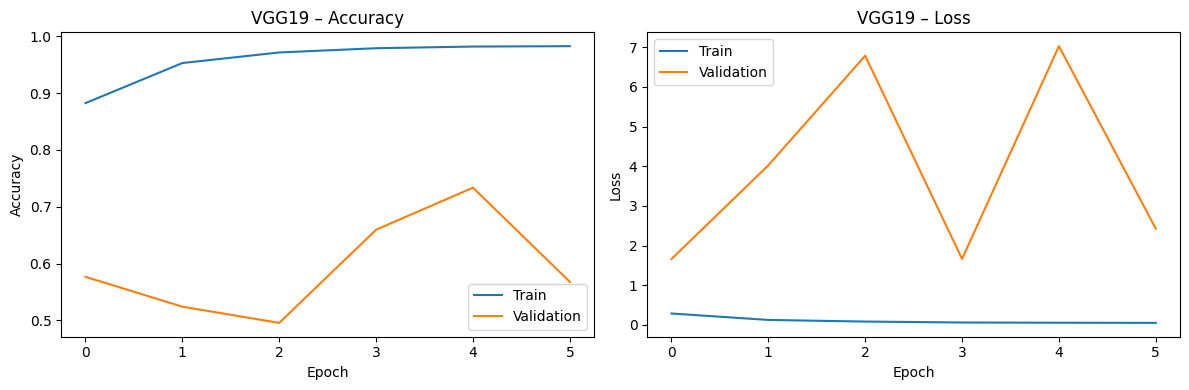


=== VGG19 ===
Accuracy:  0.5025
Recall:    1.0000
Precision: 0.5012
F1-score:  0.6678
AUC-ROC:   0.9109
EER:       0.1667
Bootstrap: 0.5025 [0.4669, 0.5368]


In [11]:
from tensorflow.keras.applications import VGG19

base = VGG19(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19 = models.Model(inputs, outputs)
vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg19.summary()

history_vgg19 = vgg19.fit(
    X_train_vgg, y_train,
    validation_data=(X_val_vgg, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19")
)

plot_history(history_vgg19, "VGG19")
results_vgg19 = evaluate_model(vgg19, X_test_vgg, y_test, "VGG19")

###Model 8: ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

X_train_resnet = to_rgb_resized(X_train, 224)
X_val_resnet   = to_rgb_resized(X_val,   224)
X_test_resnet  = to_rgb_resized(X_test,  224)

X_train_resnet = resnet_preprocess(X_train_resnet * 255.0)
X_val_resnet   = resnet_preprocess(X_val_resnet   * 255.0)
X_test_resnet  = resnet_preprocess(X_test_resnet  * 255.0)

base = ResNet50(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

resnet50 = models.Model(inputs, outputs)
resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet50.summary()

history_resnet50 = resnet50.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("resnet50")
)

plot_history(history_resnet50, "ResNet50")
results_resnet50 = evaluate_model(resnet50, X_test_resnet, y_test, "ResNet50")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 4,732,161 (18.05 MB)

 Non-trainable params: 19,126,144 (72.96 MB)

Epoch 1/50
151/319 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.8293 - loss: 0.4263

###Results for pretrained

In [ ]:
print("Best validation accuracies:")
print(f"MobileNet:               {max(history_mobilenet_2.history['val_accuracy']):.4f}")
print(f"VGG16:                   {max(history_vgg16.history['val_accuracy']):.4f}")
print(f"VGG19:                   {max(history_vgg19.history['val_accuracy']):.4f}")
print(f"ResNet50:                {max(history_resnet50.history['val_accuracy']):.4f}")

In [ ]:
all_results = [
    results_mobilenet,
    results_vgg16,
    results_vgg19,
    results_resnet50
]

df_results = pd.DataFrame(all_results).set_index("model").round(4)
print(df_results.to_string())

#MEL

###Imports and parametre

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, shutil

drive_path = "/content/drive/MyDrive/Speciale/for-rerecorded 2"
local_path = "/content/for-rerec"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

base_path  = local_path
train_path = os.path.join(base_path, "training")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "testing")

Mounted at /content/drive


In [2]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR         = 16000
DURATION   = 2.0
TARGET_LEN = int(SR * DURATION)
N_MELS     = 128
N_FFT      = 1024
HOP_LENGTH = 256
BATCH_SIZE = 32
EPOCHS     = 50
INITIAL_LR = 3e-4

base_path  = "/content/for-rerec"
train_path = os.path.join(base_path, "training")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "testing")

Mel function and load data

In [3]:
def create_mel(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype(np.float32)

def get_paths(split_path):
    real = sorted([
        os.path.join(split_path, "real", f)
        for f in os.listdir(os.path.join(split_path, "real"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(split_path, "fake", f)
        for f in os.listdir(os.path.join(split_path, "fake"))
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(split_path):
    real, fake = get_paths(split_path)
    X, y = [], []
    for fp in real:
        X.append(create_mel(fp))
        y.append(1)
    for fp in fake:
        X.append(create_mel(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading train...")
X_train, y_train = load_split(train_path)
print("Loading val...")
X_val, y_val = load_split(val_path)
print("Loading test...")
X_test, y_test = load_split(test_path)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Loading train...
Loading val...
Loading test...
Train: (10208, 128, 126)
Val:   (2244, 128, 126)
Test:  (816, 128, 126)


Z-score normalisering

In [4]:
mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)

Train shape: (10208, 128, 126, 1)
Val shape:   (2244, 128, 126, 1)
Test shape:  (816, 128, 126, 1)


Help function

In [5]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(f"/content/{model_name}.keras", monitor="val_loss", save_best_only=True, verbose=1)
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

SpecAugment og residual block

In [6]:
class SpecAugment(layers.Layer):
    def __init__(self, freq_mask=10, time_mask=15, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask = freq_mask
        self.time_mask = time_mask

    def call(self, x, training=None):
        if not training:
            return x
        freq = tf.shape(x)[1]
        time = tf.shape(x)[2]

        f  = tf.random.uniform([], 0, self.freq_mask, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, freq - f, dtype=tf.int32)
        freq_mask = 1.0 - tf.cast(
            tf.sequence_mask(f, freq) & ~tf.sequence_mask(f0, freq),
            dtype=x.dtype
        )
        freq_mask = tf.reshape(freq_mask, [1, freq, 1, 1])
        x = x * freq_mask

        t  = tf.random.uniform([], 0, self.time_mask, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, time - t, dtype=tf.int32)
        time_mask = 1.0 - tf.cast(
            tf.sequence_mask(t, time) & ~tf.sequence_mask(t0, time),
            dtype=x.dtype
        )
        time_mask = tf.reshape(time_mask, [1, 1, time, 1])
        x = x * time_mask
        return x

def residual_block(x, filters):
    shortcut = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

### Model 1: Simple CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 63, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       983,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,006,465 (3.84 MB)

 Trainable params: 1,006,465 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
317/319 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7256 - loss: 0.5213
Epoch 1: val_loss improved from None to 0.32597, saving model to /content/simple_cnn_mel.keras

Epoch 1: finished saving model to /content/simple_cnn_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8068 - loss: 0.4093 - val_accuracy: 0.8471 - val_loss: 0.3260
Epoch 2/50
317/319 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9025 - loss: 0.2451
Epoch 2: val_loss improved from 0.32597 to 0.16922, saving model to /content/simple_cnn_mel.keras

Epoch 2: finished saving model to /content/simple_cnn_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9084 - loss: 0.2276 - val_accuracy: 0.9309 - val_loss: 0.1692
Epoch 3/50
314/319 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9343 - loss: 0.1600
Epoch 3: val_loss improved from 0.16922 to 0.15051, saving model to /content/simple_cnn_mel.keras

Epoch 3: finished saving model to /content/simple_cnn_mel.keras
319/319 ━━━━━━━━

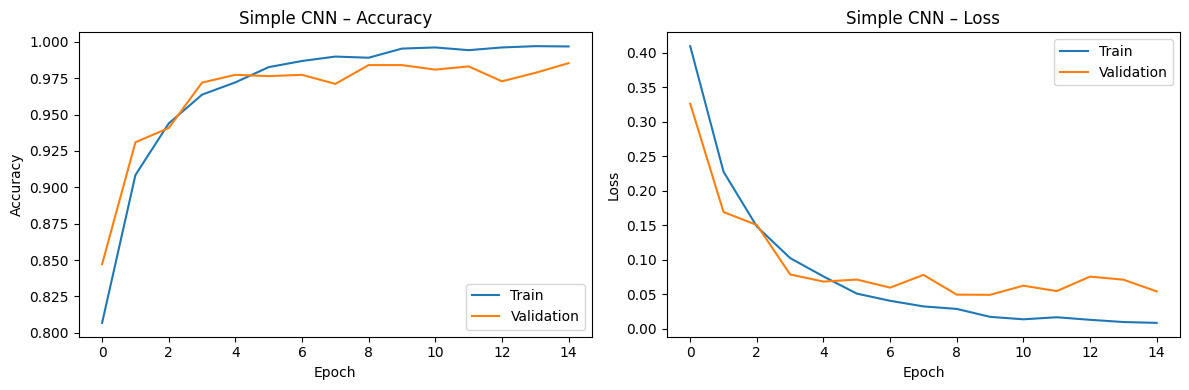


=== Simple CNN ===
Accuracy:  0.7966
Recall:    0.9461
Precision: 0.7283
F1-score:  0.8230
AUC-ROC:   0.8732
EER:       0.2034
Bootstrap: 0.7960 [0.7684, 0.8223]


In [7]:
input_shape = X_train.shape[1:]

simple_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
simple_cnn.summary()

history_simple = simple_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_cnn_mel")
)
plot_history(history_simple, "Simple CNN")
results_simple = evaluate_model(simple_cnn, X_test, y_test, "Simple CNN")

###Model 2: Improved CNN

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 126,  │        288 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 126,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 63,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 63,    │      2,336 │ max_pooling2d_3[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 64, 63,    │      4,672 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 63,    │      2,048 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 63,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 63,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 31,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 32, 31,    │      8,768 │ max_pooling2d_4[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 31,    │        512 │ separable_conv2d

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7914 - loss: 0.4213
Epoch 1: val_loss improved from None to 1.23445, saving model to /content/improved_cnn_mel.keras

Epoch 1: finished saving model to /content/improved_cnn_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.8743 - loss: 0.2877 - val_accuracy: 0.4906 - val_loss: 1.2344
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9583 - loss: 0.1170
Epoch 2: val_loss improved from 1.23445 to 0.71313, saving model to /content/improved_cnn_mel.keras

Epoch 2: finished saving model to /content/improved_cnn_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9593 - loss: 0.1136 - val_accuracy: 0.6515 - val_loss: 0.7131
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9756 - loss: 0.0676
Epoch 3: val_loss improved from 0.71313 to 0.09764, saving model to /content/improved_cnn_mel.keras

Epoch 3: finished saving model to /content/improved_cnn_mel.keras
319

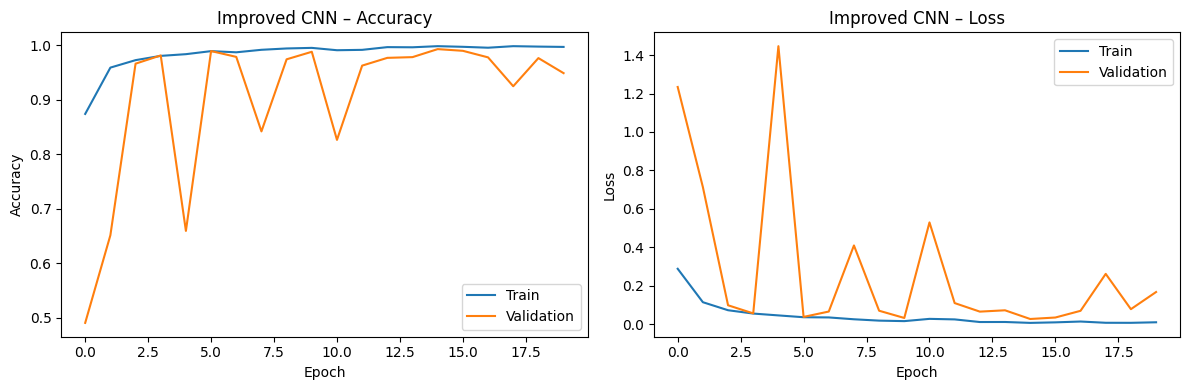


=== Improved CNN ===
Accuracy:  0.6691
Recall:    0.9657
Precision: 0.6062
F1-score:  0.7448
AUC-ROC:   0.8413
EER:       0.2377
Bootstrap: 0.6685 [0.6373, 0.6998]


In [8]:
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn = models.Model(inputs, outputs)
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn.summary()

history_improved = improved_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_mel")
)
plot_history(history_improved, "Improved CNN")
results_improved = evaluate_model(improved_cnn, X_test, y_test, "Improved CNN")

###Model 3: Improved CNN + SpecAugment

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spec_augment        │ (None, 128, 126,  │          0 │ input_layer_2[0]… │
│ (SpecAugment)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 126,  │        288 │ spec_augment[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 63,    │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 64, 63,    │      2,336 │ max_pooling2d_6[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 64, 63,    │      4,672 │ activation_8[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 63,    │      2,048 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 63,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64, 63,    │          0 │ add_3[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 31,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 32, 31,    │      8,768 │ max_pooling2d_7[

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7872 - loss: 0.4215
Epoch 1: val_loss improved from None to 0.81915, saving model to /content/improved_cnn_aug_mel.keras

Epoch 1: finished saving model to /content/improved_cnn_aug_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.8703 - loss: 0.2909 - val_accuracy: 0.5094 - val_loss: 0.8191
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9471 - loss: 0.1392
Epoch 2: val_loss improved from 0.81915 to 0.35728, saving model to /content/improved_cnn_aug_mel.keras

Epoch 2: finished saving model to /content/improved_cnn_aug_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9502 - loss: 0.1324 - val_accuracy: 0.8525 - val_loss: 0.3573
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9698 - loss: 0.0876
Epoch 3: val_loss improved from 0.35728 to 0.15248, saving model to /content/improved_cnn_aug_mel.keras

Epoch 3: finished saving model to /content/improv

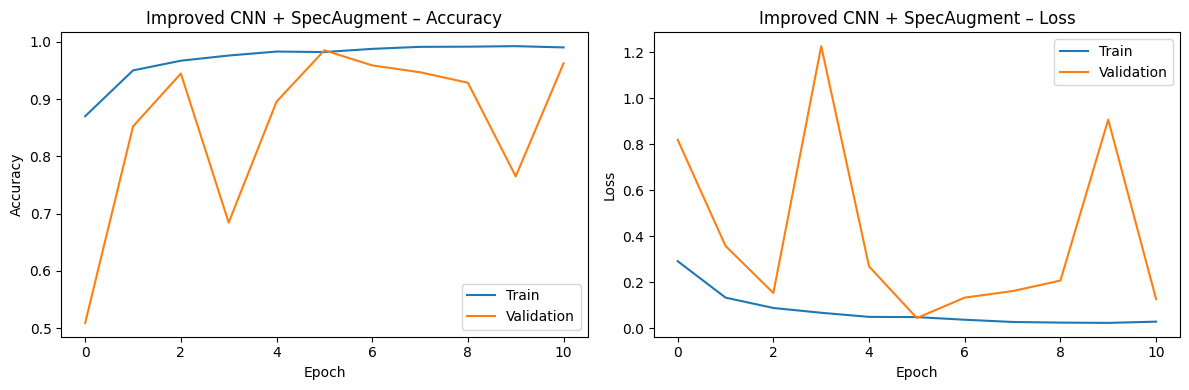


=== Improved CNN + SpecAugment ===
Accuracy:  0.7034
Recall:    0.9240
Precision: 0.6412
F1-score:  0.7570
AUC-ROC:   0.8183
EER:       0.2525
Bootstrap: 0.7031 [0.6728, 0.7328]


In [9]:
inputs = layers.Input(shape=input_shape)
x = SpecAugment()(inputs)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn_aug = models.Model(inputs, outputs)
improved_cnn_aug.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn_aug.summary()

history_improved_aug = improved_cnn_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_aug_mel")
)
plot_history(history_improved_aug, "Improved CNN + SpecAugment")
results_improved_aug = evaluate_model(improved_cnn_aug, X_test, y_test, "Improved CNN + SpecAugment")

###Model 4: Mini-Xception

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 128, 126,  │        288 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 128, 126,  │      1,312 │ activation_14[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 128, 126,  │      1,312 │ activation_15[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 64, 63,    │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 64, 63,    │          0 │ max_pooling2d_9[… │
│                     │ 32)               │            │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_14 │ (None, 64, 63,    │      2,336 │ add_6[0][0]       │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_15 │ (None, 64, 63,    │      4,672 │ activation_16[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 63,    │      2,048 │ add_6[0][0]     

 Total params: 187,009 (730.50 KB)

 Trainable params: 184,129 (719.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7500 - loss: 0.5408
Epoch 1: val_loss improved from None to 1.77149, saving model to /content/mini_xception_mel.keras

Epoch 1: finished saving model to /content/mini_xception_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 57s 103ms/step - accuracy: 0.8423 - loss: 0.3572 - val_accuracy: 0.4906 - val_loss: 1.7715
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9403 - loss: 0.1489
Epoch 2: val_loss did not improve from 1.77149
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.9500 - loss: 0.1284 - val_accuracy: 0.4955 - val_loss: 2.5090
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9678 - loss: 0.0863
Epoch 3: val_loss improved from 1.77149 to 0.21509, saving model to /content/mini_xception_mel.keras

Epoch 3: finished saving model to /content/mini_xception_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9722 - loss: 0.0761 - val_accuracy: 0.9242 - val_loss: 0.2151

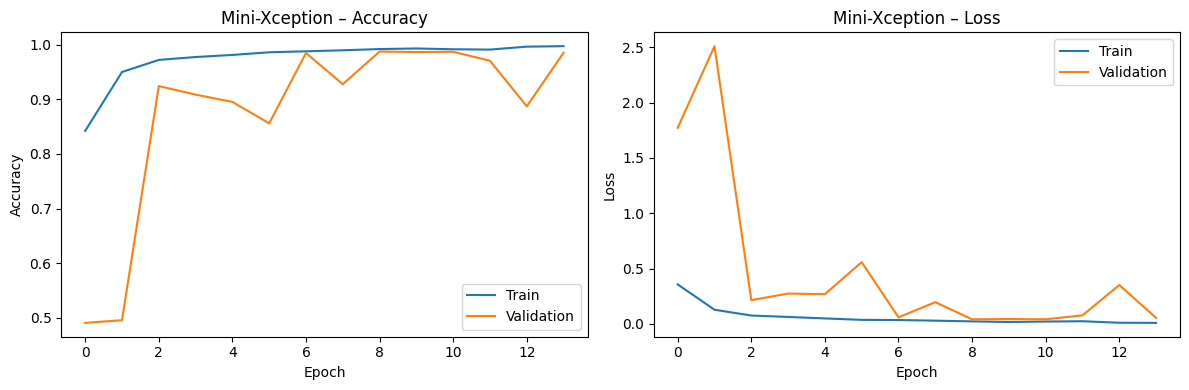


=== Mini-Xception ===
Accuracy:  0.5380
Recall:    0.9804
Precision: 0.5202
F1-score:  0.6797
AUC-ROC:   0.7509
EER:       0.3113
Bootstrap: 0.5384 [0.5012, 0.5723]


In [10]:
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

for filters in [32, 64, 128, 256]:
    residual = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding="same")(x)
    if residual.shape[-1] != filters:
        residual = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(residual)
        residual = layers.BatchNormalization()(residual)
    residual = layers.MaxPooling2D((2,2), padding="same")(residual)
    x = layers.Add()([x, residual])

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mini_xception = models.Model(inputs, outputs)
mini_xception.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mini_xception.summary()

history_xception = mini_xception.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mini_xception_mel")
)
plot_history(history_xception, "Mini-Xception")
results_xception = evaluate_model(mini_xception, X_test, y_test, "Mini-Xception")

###Results for not pretrained

In [11]:
all_results = [
    results_simple, results_improved, results_improved_aug,
    results_xception
]

df_results = pd.DataFrame(all_results).set_index("model").round(4)
print("\n=== Mel 128 – Test results ===")
print(df_results.to_string())

print("\nBest validation accuracies:")
print(f"Simple CNN:             {max(history_simple.history['val_accuracy']):.4f}")
print(f"Improved CNN:           {max(history_improved.history['val_accuracy']):.4f}")
print(f"Improved CNN + SpecAug: {max(history_improved_aug.history['val_accuracy']):.4f}")
print(f"Mini-Xception:          {max(history_xception.history['val_accuracy']):.4f}")


=== Mel 128 – Test results ===
                            accuracy  recall  precision      f1     auc     eer  ci_low  ci_high
model                                                                                           
Simple CNN                    0.7966  0.9461     0.7283  0.8230  0.8732  0.2034  0.7684   0.8223
Improved CNN                  0.6691  0.9657     0.6062  0.7448  0.8413  0.2377  0.6373   0.6998
Improved CNN + SpecAugment    0.7034  0.9240     0.6412  0.7570  0.8183  0.2525  0.6728   0.7328
Mini-Xception                 0.5380  0.9804     0.5202  0.6797  0.7509  0.3113  0.5012   0.5723

Best validation accuracies:
Simple CNN:             0.9853
Improved CNN:           0.9933
Improved CNN + SpecAug: 0.9853
Mini-Xception:          0.9875


###Model 5: MobileNet

RGB konvertering

In [12]:
def to_rgb_resized(X, size, batch_size=100):
    results = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        batch_rgb = tf.repeat(batch, repeats=3, axis=-1)
        batch_rgb = tf.image.resize(batch_rgb, (size, size)).numpy()
        results.append(batch_rgb.astype(np.float32))
    return np.concatenate(results, axis=0)

X_train_rgb96 = to_rgb_resized(X_train, 96)
X_val_rgb96   = to_rgb_resized(X_val,   96)
X_test_rgb96  = to_rgb_resized(X_test,  96)

X_train_vgg = to_rgb_resized(X_train, 224)
X_val_vgg   = to_rgb_resized(X_val,   224)
X_test_vgg  = to_rgb_resized(X_test,  224)

print("RGB 96:", X_train_rgb96.shape)
print("VGG 224:", X_train_vgg.shape)

RGB 96: (10208, 96, 96, 3)
VGG 224: (10208, 224, 224, 3)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 733,761 (2.80 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7702 - loss: 0.5306
Epoch 1: val_loss improved from None to 4.10371, saving model to /content/mobilenet_finetuned_mel.keras

Epoch 1: finished saving model to /content/mobilenet_finetuned_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.8052 - loss: 0.4419 - val_accuracy: 0.5094 - val_loss: 4.1037
Epoch 2/50
318/319 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8663 - loss: 0.3082
Epoch 2: val_loss improved from 4.10371 to 3.31557, saving model to /content/mobilenet_finetuned_mel.keras

Epoch 2: finished saving model to /content/mobilenet_finetuned_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8662 - loss: 0.3045 - val_accuracy: 0.5094 - val_loss: 3.3156
Epoch 3/50
316/319 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8921 - loss: 0.2600
Epoch 3: val_loss did not improve from 3.31557
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8888 - loss: 0.2588 - val_accuracy: 0.50

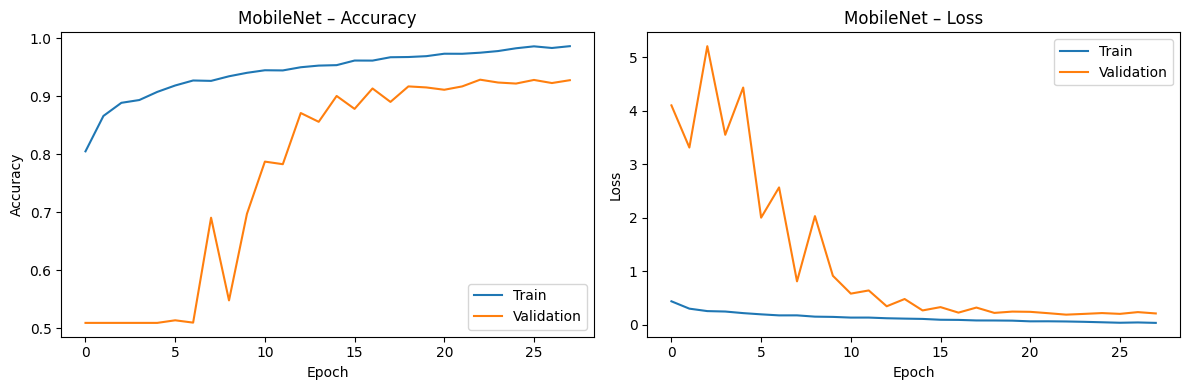


=== MobileNet ===
Accuracy:  0.6985
Recall:    0.8162
Precision: 0.6607
F1-score:  0.7303
AUC-ROC:   0.7930
EER:       0.2868
Bootstrap: 0.6980 [0.6667, 0.7279]


In [13]:
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
base.trainable = False

inputs  = layers.Input(shape=(96, 96, 3))
x       = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x       = base(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet = models.Model(inputs, outputs)
mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mobilenet.summary()

history_mobilenet_1 = mobilenet.fit(
    X_train_rgb96, y_train,
    validation_data=(X_val_rgb96, y_val),
    epochs=10, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mobilenet_mel")
)

base.trainable = True
for layer in base.layers[:-10]:
    layer.trainable = False

mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mobilenet.summary()

history_mobilenet_2 = mobilenet.fit(
    X_train_rgb96, y_train,
    validation_data=(X_val_rgb96, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mobilenet_finetuned_mel")
)
plot_history(history_mobilenet_2, "MobileNet")
results_mobilenet = evaluate_model(mobilenet, X_test_rgb96, y_test, "MobileNet")

###Model 6: VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,529 (56.39 MB)

 Trainable params: 7,146,241 (27.26 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8957 - loss: 0.2387
Epoch 1: val_loss improved from None to 0.42334, saving model to /content/vgg16_mel.keras

Epoch 1: finished saving model to /content/vgg16_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 124s 313ms/step - accuracy: 0.9406 - loss: 0.1443 - val_accuracy: 0.8529 - val_loss: 0.4233
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9795 - loss: 0.0520
Epoch 2: val_loss improved from 0.42334 to 0.12345, saving model to /content/vgg16_mel.keras

Epoch 2: finished saving model to /content/vgg16_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 92s 287ms/step - accuracy: 0.9807 - loss: 0.0529 - val_accuracy: 0.9554 - val_loss: 0.1235
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9857 - loss: 0.0390
Epoch 3: val_loss improved from 0.12345 to 0.08695, saving model to /content/vgg16_mel.keras

Epoch 3: finished saving model to /content/vgg16_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 92s 289ms/

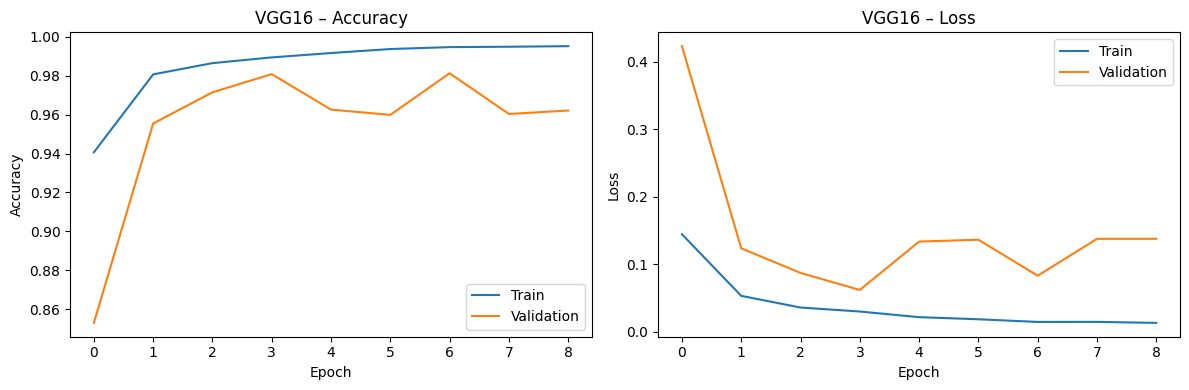


=== VGG16 ===
Accuracy:  0.7512
Recall:    0.9338
Precision: 0.6840
F1-score:  0.7896
AUC-ROC:   0.9022
EER:       0.1838
Bootstrap: 0.7508 [0.7218, 0.7794]


In [14]:
from tensorflow.keras.applications import VGG16

def build_vgg(vgg_class):
    base = vgg_class(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-5:]:
        layer.trainable = True

    inputs  = layers.Input(shape=(224, 224, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation="relu")(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    return model

vgg16 = build_vgg(VGG16)

history_vgg16 = vgg16.fit(
    X_train_vgg, y_train,
    validation_data=(X_val_vgg, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg16_mel")
)
plot_history(history_vgg16, "VGG16")
results_vgg16 = evaluate_model(vgg16, X_test_vgg, y_test, "VGG16")

###Model 7: VGG19

In [19]:
from tensorflow.keras.applications import VGG19

base = VGG19(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19 = models.Model(inputs, outputs)
vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
vgg19.summary()

history_vgg19 = vgg19.fit(
    X_train_vgg, y_train,
    validation_data=(X_val_vgg, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_mel")
)
plot_history(history_vgg19, "VGG19")
results_vgg19 = evaluate_model(vgg19, X_test_vgg, y_test, "VGG19")

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,092,225 (76.65 MB)

 Trainable params: 17,765,633 (67.77 MB)

 Non-trainable params: 2,326,592 (8.88 MB)

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

###Model 8: ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 4,732,161 (18.05 MB)

 Non-trainable params: 19,126,144 (72.96 MB)

Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8632 - loss: 0.3460
Epoch 1: val_loss improved from None to 0.10951, saving model to /content/resnet50_mel.keras

Epoch 1: finished saving model to /content/resnet50_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 77s 178ms/step - accuracy: 0.9120 - loss: 0.2331 - val_accuracy: 0.9590 - val_loss: 0.1095
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9653 - loss: 0.0898
Epoch 2: val_loss improved from 0.10951 to 0.08657, saving model to /content/resnet50_mel.keras

Epoch 2: finished saving model to /content/resnet50_mel.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 46s 143ms/step - accuracy: 0.9663 - loss: 0.0870 - val_accuracy: 0.9701 - val_loss: 0.0866
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9780 - loss: 0.0620
Epoch 3: val_loss improved from 0.08657 to 0.06439, saving model to /content/resnet50_mel.keras

Epoch 3: finished saving model to /content/resnet50_mel.keras
319/319 ━━━━━━━━━━━━━━

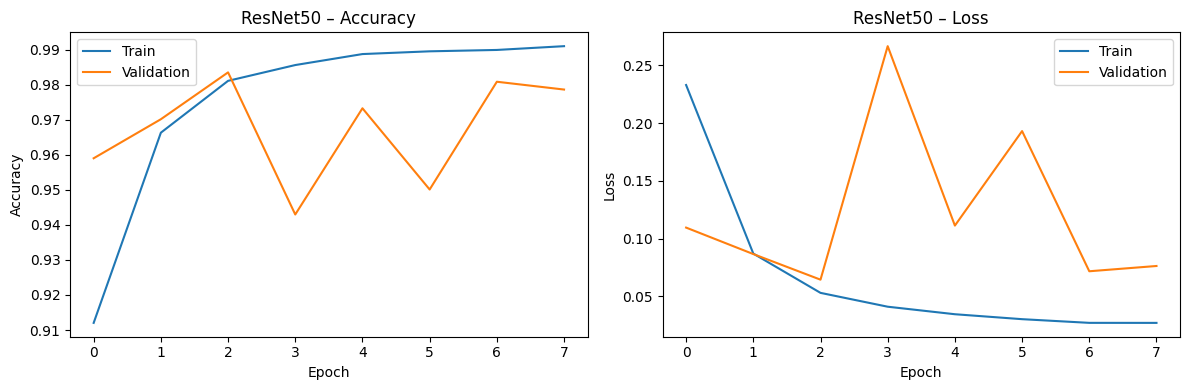


=== ResNet50 ===
Accuracy:  0.6581
Recall:    0.8088
Precision: 0.6215
F1-score:  0.7029
AUC-ROC:   0.7675
EER:       0.3113
Bootstrap: 0.6587 [0.6237, 0.6912]


In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

X_train_resnet = to_rgb_resized(X_train, 224)
X_val_resnet   = to_rgb_resized(X_val,   224)
X_test_resnet  = to_rgb_resized(X_test,  224)

X_train_resnet = resnet_preprocess(X_train_resnet * 255.0)
X_val_resnet   = resnet_preprocess(X_val_resnet   * 255.0)
X_test_resnet  = resnet_preprocess(X_test_resnet  * 255.0)

base = ResNet50(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

resnet50 = models.Model(inputs, outputs)
resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
resnet50.summary()

history_resnet50 = resnet50.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("resnet50_mel")
)
plot_history(history_resnet50, "ResNet50")
results_resnet50 = evaluate_model(resnet50, X_test_resnet, y_test, "ResNet50")

###Results for pretrained

In [17]:
all_results = [
    results_mobilenet, results_vgg16,
    results_vgg19, results_resnet50
]

df_results = pd.DataFrame(all_results).set_index("model").round(4)
print("\n=== Mel 128 – Test results ===")
print(df_results.to_string())

print("\nBest validation accuracies:")
print(f"MobileNet:              {max(history_mobilenet_2.history['val_accuracy']):.4f}")
print(f"VGG16:                  {max(history_vgg16.history['val_accuracy']):.4f}")
print(f"VGG19:                  {max(history_vgg19.history['val_accuracy']):.4f}")
print(f"ResNet50:               {max(history_resnet50.history['val_accuracy']):.4f}")


=== Mel 128 – Test results ===
           accuracy  recall  precision      f1     auc     eer  ci_low  ci_high
model                                                                          
MobileNet    0.6985  0.8162     0.6607  0.7303  0.7930  0.2868  0.6667   0.7279
VGG16        0.7512  0.9338     0.6840  0.7896  0.9022  0.1838  0.7218   0.7794
VGG19        0.5000  0.0000     0.0000  0.0000  0.5000  0.0000  0.4681   0.5343
ResNet50     0.6581  0.8088     0.6215  0.7029  0.7675  0.3113  0.6237   0.6912

Best validation accuracies:
MobileNet:              0.9287
VGG16:                  0.9813
VGG19:                  0.5094
ResNet50:               0.9835


#MFCC

#CQT